Ecommerce customer behaviour analysis and recommendation systems

Data Collection

In [1]:
from google.colab import files
uploaded = files.upload()

Saving ecommerce customer segmentation_unsupervised.csv to ecommerce customer segmentation_unsupervised.csv


In [3]:
import pandas as pd

df = pd.read_csv("ecommerce customer segmentation_unsupervised.csv")


Data preparation

In [4]:
df.head()

,TransactionID,CustomerID,Product,Category,Price,Quantity,PaymentType,City,Country,TransactionDate,DiscountApplied,Rating,Browser,Device,SessionDuration,CouponCode,ReturnStatus,Warehouse,ShippingType,ReviewText
0,735,1288,Dress,Electronics,59580,2,UPI,Hyderabad,India,NaN,Yes,2.925896,Chrome,Mobile,179,OFF20,NaN,WH1,NaN,Good
1,3568,1600,Headphones,NaN,73051,3,UPI,Hyderabad,India,April 5 2023,N,2.375202,Safari,Tablet,383,NaN,Returned,NaN,Standard,Good
2,2647,1750,Laptop,Fashion,41671,1,Cash,NaN,IND,NaN,No,4.847437,Safari,NaN,257,YIrSES,Not Returned,WH2,Express,NaN
3,3636,1744,Mobile,Fashion,77354,3,Cash,NaN,IND,NaN,No,1.304575,NaN,Mobile,373,YIrSES,NaN,NaN,Standard,Bad
4,2323,1246,Dress,Accessories,13351,1,Cash,Delhi,IN,2023-01-01,NaN,4.199372,Edge,Mobile,298,OFF20,Not Returned,NaN,NaN,NaN


In [5]:
df.tail()

,TransactionID,CustomerID,Product,Category,Price,Quantity,PaymentType,City,Country,TransactionDate,DiscountApplied,Rating,Browser,Device,SessionDuration,CouponCode,ReturnStatus,Warehouse,ShippingType,ReviewText
5295,1147,1825,Shoes,Electronics,93942,2,Card,Delhi,India,02/03/2023,No,3.899491,Safari,Desktop,304,OFF20,Returned,WH2,Express,Good
5296,3150,1510,NaN,Accessories,44381,4,Card,Delhi,NaN,02/03/2023,NaN,1.624659,NaN,Desktop,249,YIrSES,NaN,WH2,NaN,Bad
5297,2930,1410,NaN,Fashion,99507,4,Cash,Hyderabad,IN,NaN,Y,1.036224,Edge,Desktop,54,OFF20,Not Returned,WH1,Express,Good
5298,4889,1473,Shoes,Electronics,62859,3,UPI,Mumbai,NaN,NaN,Y,4.272613,Safari,Tablet,354,OFF20,Returned,WH1,NaN,Bad
5299,2735,1965,Laptop,Accessories,41583,3,Card,Chennai,NaN,02/03/2023,Yes,1.098015,Safari,Mobile,124,YIrSES,Not Returned,WH2,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5300 entries, 0 to 5299
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   TransactionID    5300 non-null   int64  
 1   CustomerID       5300 non-null   int64  
 2   Product          4437 non-null   object 
 3   Category         3972 non-null   object 
 4   Price            5300 non-null   int64  
 5   Quantity         5300 non-null   int64  
 6   PaymentType      4264 non-null   object 
 7   City             4281 non-null   object 
 8   Country          3941 non-null   object 
 9   TransactionDate  4015 non-null   object 
 10  DiscountApplied  4243 non-null   object 
 11  Rating           5300 non-null   float64
 12  Browser          3938 non-null   object 
 13  Device           4019 non-null   object 
 14  SessionDuration  5300 non-null   int64  
 15  CouponCode       3986 non-null   object 
 16  ReturnStatus     3498 non-null   object 
 17  Warehouse     

In [7]:
df.describe()

,TransactionID,CustomerID,Price,Quantity,Rating,SessionDuration
count,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000
mean,2496.283962,1501.120566,50272.873208,2.536415,3.001658,251.191132
std,1443.985399,290.441794,28860.385484,1.112978,1.156071,142.949875
min,1.000000,1000.000000,111.000000,1.000000,1.000891,1.000000
25%,1248.750000,1245.000000,25105.000000,2.000000,2.004778,129.000000
50%,2495.500000,1501.000000,50745.500000,3.000000,2.993256,250.000000
75%,3746.250000,1757.000000,75561.000000,4.000000,3.998908,376.000000
max,5000.000000,1999.000000,99981.000000,4.000000,4.999242,499.000000


In [8]:
df.columns

Index(['TransactionID', 'CustomerID', 'Product', 'Category', 'Price',
       'Quantity', 'PaymentType', 'City', 'Country', 'TransactionDate',
       'DiscountApplied', 'Rating', 'Browser', 'Device', 'SessionDuration',
       'CouponCode', 'ReturnStatus', 'Warehouse', 'ShippingType',
       'ReviewText'],
      dtype='object')

In [9]:
df.shape

(5300, 20)

In [10]:
df.size

106000

Data Cleaning

Handle Null Values

In [11]:
df.isnull().sum()

,0
TransactionID,0
CustomerID,0
Product,863
Category,1328
Price,0
Quantity,0
PaymentType,1036
City,1019
Country,1359
TransactionDate,1285


In [12]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_8831/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [13]:
df.isnull().sum()

,0
TransactionID,0
CustomerID,0
Product,0
Category,0
Price,0
Quantity,0
PaymentType,0
City,0
Country,0
TransactionDate,1


Remove Duplicates

In [14]:
df.drop_duplicates(inplace=True)

Fix Formats

In [15]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')

Feature Engineering

Label Encoding

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['PaymentType'] = le.fit_transform(df['PaymentType'])
df['Browser'] = le.fit_transform(df['Browser'])

One-Hot Encoding

In [17]:
df = pd.get_dummies(df, columns=['Category', 'Device', 'ShippingType'], drop_first=True)

Feature Selection

In [27]:
df['TotalSpend'] = df['Price'] * df['Quantity']
df['Engagement'] = df['SessionDuration'] * df['Rating']

In [46]:
df['AvgSpend'] = df['TotalSpend'] / (df['Quantity'] + 1)
df['SpendPerTime'] = df['TotalSpend'] / (df['SessionDuration'] + 1)

In [50]:
features =  ['TotalSpend', 'AvgSpend', 'SpendPerTime', 'Engagement']
X = df[features]

Remove OUTLIERS

In [29]:
import numpy as np

Q1 = np.percentile(X, 25, axis=0)
Q3 = np.percentile(X, 75, axis=0)
IQR = Q3 - Q1

mask = ((X >= (Q1 - 1.5 * IQR)) & (X <= (Q3 + 1.5 * IQR))).all(axis=1)
X = X[mask]
df = df[mask]

Feature Scaling

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Find Optimal Clusters (KMeans)

Elbow Method

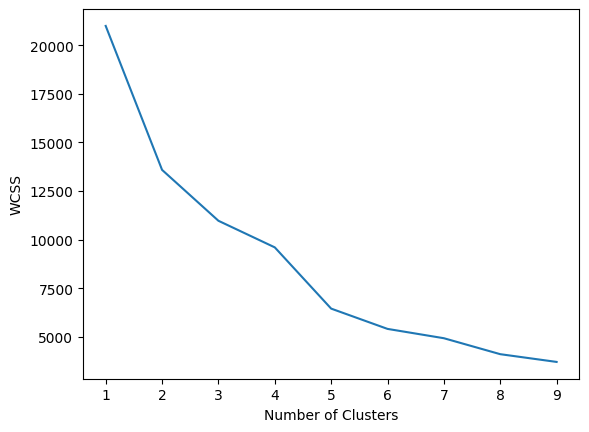

In [52]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [53]:
for k in range(2, 7):
    from sklearn.cluster import KMeans
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)

    from sklearn.metrics import silhouette_score
    score = silhouette_score(X_scaled, labels)

    print(f"K={k}, Score={score}")

K=2, Score=0.4037578494785831
K=3, Score=0.3565570161174458
K=4, Score=0.3280363213953625
K=5, Score=0.3374142006453793
K=6, Score=0.33946453078298283


In [54]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

Train Multiple Models

KMeans

In [55]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

Hierarchical

In [56]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3)
labels_hc = hc.fit_predict(X_scaled)

DBSCAN

In [57]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=5)
labels_db = db.fit_predict(X_scaled)

GMM

In [58]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=42)
labels_gmm = gmm.fit_predict(X_scaled)

Model Evaluation

In [59]:
from sklearn.metrics import silhouette_score

print("KMeans:", silhouette_score(X_scaled, labels_kmeans))
print("Hierarchical:", silhouette_score(X_scaled, labels_hc))

# DBSCAN only if more than 1 cluster
if len(set(labels_db)) > 1:
    print("DBSCAN:", silhouette_score(X_scaled, labels_db))

print("GMM:", silhouette_score(X_scaled, labels_gmm))

KMeans: 0.3565570161174458
Hierarchical: 0.32365077999529646
DBSCAN: 0.3714294550324338
GMM: 0.17060416810178136


In [60]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

for eps in [0.2, 0.3, 0.4, 0.5]:
    for min_samples in [3, 5, 7]:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)

        if len(set(labels)) > 1:
            score = silhouette_score(X_scaled, labels)
            print(f"eps={eps}, min_samples={min_samples}, score={score}")

eps=0.2, min_samples=3, score=-0.3719578374199907
eps=0.2, min_samples=5, score=-0.3353313056674133
eps=0.2, min_samples=7, score=-0.33861652739127496
eps=0.3, min_samples=3, score=0.026389894036304467
eps=0.3, min_samples=5, score=0.16070779309974118
eps=0.3, min_samples=7, score=0.023155417198060513
eps=0.4, min_samples=3, score=0.24017587759251344
eps=0.4, min_samples=5, score=0.36019294022503084
eps=0.4, min_samples=7, score=0.36132256433776655
eps=0.5, min_samples=3, score=0.45315563066405784
eps=0.5, min_samples=5, score=0.3714294550324338
eps=0.5, min_samples=7, score=0.35777867655201423


In [61]:
set(labels)

{np.int64(-1), np.int64(0), np.int64(1), np.int64(2)}

Recommendation System (Association Rule Learning)

In [63]:
basket = df.groupby(['CustomerID', 'Product'])['Quantity'].sum().unstack().fillna(0)

In [64]:
basket = basket.applymap(lambda x: 1 if x > 0 else 0)

/tmp/ipykernel_8831/3498954818.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = basket.applymap(lambda x: 1 if x > 0 else 0)


In [65]:
from mlxtend.frequent_patterns import apriori, association_rules

freq_items = apriori(basket, min_support=0.05, use_colnames=True)

/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [66]:
rules = association_rules(freq_items, metric="lift", min_threshold=1)
rules.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Dress),(Shoes),0.656627,0.630522,0.414659,0.631498,1.001549,1.0,0.000641,1.002650,0.004503,0.475259,0.002643,0.644571
1,(Shoes),(Dress),0.630522,0.656627,0.414659,0.657643,1.001549,1.0,0.000641,1.002970,0.004185,0.475259,0.002961,0.644571
2,(Mobile),(Headphones),0.631526,0.651606,0.418675,0.662957,1.017419,1.0,0.007168,1.033677,0.046465,0.484321,0.032580,0.652742
3,(Headphones),(Mobile),0.651606,0.631526,0.418675,0.642527,1.017419,1.0,0.007168,1.030774,0.049143,0.484321,0.029855,0.652742
4,(Laptop),(Mobile),0.629518,0.631526,0.398594,0.633174,1.002609,1.0,0.001037,1.004492,0.007024,0.462165,0.004472,0.632167


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [67]:
from mlxtend.frequent_patterns import fpgrowth

freq_fp = fpgrowth(basket, min_support=0.05, use_colnames=True)
rules_fp = association_rules(freq_fp, metric="lift", min_threshold=1)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [68]:
rules.sort_values(by='lift', ascending=False).head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
29,"(Dress, Mobile)","(Shoes, Headphones)",0.400602,0.409639,0.170683,0.426065,1.040100,1.0,0.006581,1.028621,0.064322,0.266876,0.027825,0.421366
32,"(Shoes, Headphones)","(Dress, Mobile)",0.409639,0.400602,0.170683,0.416667,1.040100,1.0,0.006581,1.027539,0.065306,0.266876,0.026801,0.421366
35,(Headphones),"(Dress, Shoes, Mobile)",0.651606,0.253012,0.170683,0.261941,1.035292,1.0,0.005818,1.012098,0.097847,0.232558,0.011954,0.468272
26,"(Dress, Shoes, Mobile)",(Headphones),0.253012,0.651606,0.170683,0.674603,1.035292,1.0,0.005818,1.070673,0.045636,0.232558,0.066008,0.468272
41,"(Laptop, Shoes, Headphones)","(Dress, Mobile)",0.245984,0.400602,0.101406,0.412245,1.029062,1.0,0.002864,1.019808,0.037455,0.186004,0.019424,0.332689


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [69]:
df.to_csv("final_data.csv", index=False)
rules.to_csv("rules.csv", index=False)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [70]:
df['Cluster'] = labels   # or labels_db

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [73]:
df.to_csv("final_data.csv", index=False)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [72]:
df.columns

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Index(['TransactionID', 'CustomerID', 'Product', 'Price', 'Quantity',
       'PaymentType', 'City', 'Country', 'TransactionDate', 'DiscountApplied',
       'Rating', 'Browser', 'SessionDuration', 'CouponCode', 'ReturnStatus',
       'Warehouse', 'ReviewText', 'Category_Electronics', 'Category_Fashion',
       'Device_Mobile', 'Device_Tablet', 'ShippingType_Standard', 'TotalSpend',
       'Engagement', 'AvgSpend', 'SpendPerTime', 'Cluster'],
      dtype='object')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag